# Task 1.2: Logistic Regression from Scratch (Is the Case Closed?)

Goal: predict whether a crime case is closed (`closed` = Yes or No) using logistic regression built from scratch with NumPy and gradient descent. No library creates the model for me. Pandas is used to read and clean the data, NumPy for the matrix maths and Matplotlib for the plots.

The model is trained only on `crime_train.csv`. The test file is never used to train the model. It is only used to measure the accuracy.

Evaluation metric: accuracy (the % of cases predicted correctly).

## Step 1: Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 2: Load the data

`crime_train.csv` is used for training and `crime_test.csv` for testing.

In [2]:
train = pd.read_csv("crime_train.csv")
test = pd.read_csv("crime_test.csv")
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (22489, 12)
Test shape: (9639, 12)


,Unnamed: 0,Num,case_filed,city,area,crime_description,age,sex,weapon,domain,police_department,closed
0,19794,19795,04-04-2022 18:00,Mumbai,307,VEHICLE - STOLEN,63.0,X,Poison,Violent Crime,12.0,No
1,13762,13763,07-27-2021 10:00,Surat,504,ROBBERY,57.0,F,Explosives,Violent Crime,3.0,No
2,30311,30312,06-16-2023 23:00,Thane,493,ASSAULT,33.0,F,Firearm,Violent Crime,18.0,No
3,5043,5044,07-29-2020 03:00,Ahmedabad,169,PUBLIC INTOXICATION,76.0,F,Knife,Other Crime,3.0,No
4,35008,35009,12-29-2023 16:00,Mumbai,133,PUBLIC INTOXICATION,13.0,M,NaN,Other Crime,13.0,No


## Step 3: Look at the data

Before building the model I check three things: how balanced the two classes are, whether there are missing values or odd values, and whether the columns seem related to `closed`.

In [3]:
# turn the answer into numbers: Yes = 1, No = 0
answer = {"No": 0, "Yes": 1}
train["closed"] = train["closed"].map(answer)
test["closed"] = test["closed"].map(answer)

print("Share of closed cases in train:", round(train["closed"].mean(), 4))
print("Share of closed cases in test: ", round(test["closed"].mean(), 4))
print()

print("Missing values in train:")
print(train.isna().sum()[train.isna().sum() > 0])
print()

print("Odd values in train:")
print("  age above 100:", (train["age"] > 100).sum())
print("  police_department outside 1 to 19:",
      ((train["police_department"] < 1) | (train["police_department"] > 19)).sum())
print()

# share of closed cases for each value of a few columns
for col in ["sex", "weapon", "domain"]:
    print(train.groupby(col, dropna=False)["closed"].mean().round(3))
    print()

Share of closed cases in train: 0.5004
Share of closed cases in test:  0.5004

Missing values in train:
weapon    3272
dtype: int64

Odd values in train:
  age above 100: 17
  police_department outside 1 to 19: 1153

sex
F    0.500
M    0.499
X    0.509
Name: closed, dtype: float64

weapon
Blunt Object    0.502
Explosives      0.482
Firearm         0.489
Knife           0.499
Other           0.513
Poison          0.510
NaN             0.507
Name: closed, dtype: float64

domain
Fire Accident       0.487
Other Crime         0.498
Traffic Fatality    0.511
Violent Crime       0.508
Name: closed, dtype: float64



What this shows:

- The two classes are almost perfectly balanced (about 50% closed and 50% not closed). So always guessing one class gives about 50% accuracy. That is the baseline to beat.
- `weapon` is the only column with missing values. An empty weapon most likely means "no weapon", so I treat it as its own category.
- Some values are not possible: a few ages are above 100, and over a thousand `police_department` values are outside the real range of 1 to 19. These are outliers.
- In every column I checked, the share of closed cases is about 0.5 for every value. No single column separates closed cases from open ones.

## Step 4: Clean the data and choose the columns

- `Unnamed: 0` and `Num` are just row numbers, so I drop them.
- `case_filed` is text like `04-04-2022 18:00` (month-day-year hour:minute). I cut it into `month`, `day`, `year` and `hour` using slicing.
- Empty `weapon` cells become the category `None`.
- Outliers: I cap (clip) `age` at 100 and `police_department` to the range 1 to 19. Capping keeps the row but removes the impossible value. The limits are fixed numbers, not calculated from the data, so nothing leaks from the test file.
- `domain` is completely decided by `crime_description` (each crime type always has the same domain), so it adds no new information and I drop it.

In [4]:
for df in [train, test]:
    df["month"] = df["case_filed"].str[0:2].astype(int)
    df["day"] = df["case_filed"].str[3:5].astype(int)
    df["year"] = df["case_filed"].str[6:10].astype(int)
    df["hour"] = df["case_filed"].str[11:13].astype(int)
    df["weapon"] = df["weapon"].fillna("None")
    df["age"] = df["age"].clip(upper=100)
    df["police_department"] = df["police_department"].clip(lower=1, upper=19)

train = train.drop(columns=["Unnamed: 0", "Num", "case_filed", "domain"])
test = test.drop(columns=["Unnamed: 0", "Num", "case_filed", "domain"])

number_columns = ["area", "age", "police_department", "month", "day", "year", "hour"]
word_columns = ["city", "crime_description", "sex", "weapon"]

print("Missing values left in train:", train.isna().sum().sum())
print("Missing values left in test: ", test.isna().sum().sum())
print("age range now:", train["age"].min(), "to", train["age"].max())
print("police_department range now:", train["police_department"].min(), "to", train["police_department"].max())

Missing values left in train: 0
Missing values left in test:  0
age range now: 4.9 to 100.0
police_department range now: 1.0 to 19.0


## Step 5: Turn the words into numbers (one-hot encoding)

`city`, `crime_description`, `sex` and `weapon` are words. For every value I make a 0/1 column. The values come from the train data and the same columns are made for the test data.

In [5]:
for col in word_columns:
    for value in train[col].unique():
        name = col + "_" + value
        train[name] = (train[col] == value).astype(int)
        test[name] = (test[col] == value).astype(int)
    train = train.drop(columns=[col])
    test = test.drop(columns=[col])
    train = train.copy()
    test = test.copy()

feature_columns = [c for c in train.columns if c != "closed"]
print("Number of input columns:", len(feature_columns))

Number of input columns: 67


## Step 6: Make the NumPy arrays and scale them

Gradient descent works much better when all inputs are on a similar scale. I standardize the number columns with (value - mean) / std. The mean and std come from the **train** data only and are reused on the test data. The 0/1 columns are left as they are. The answer `closed` is already 0 or 1, so it is not scaled.

I also add a column of 1s so the model can learn the bias term (b).

In [6]:
# scale only the number columns, using the train mean and std
mean = train[number_columns].mean()
std = train[number_columns].std()
train[number_columns] = (train[number_columns] - mean) / std
test[number_columns] = (test[number_columns] - mean) / std

X_train = train[feature_columns].to_numpy(dtype=float)
y_train = train["closed"].to_numpy(dtype=float)
X_test = test[feature_columns].to_numpy(dtype=float)
y_test = test["closed"].to_numpy(dtype=float)

# add the column of 1s for the bias
X_train = np.c_[np.ones(len(X_train)), X_train]
X_test = np.c_[np.ones(len(X_test)), X_test]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (22489, 68)
X_test shape: (9639, 68)


## Step 7: The model, the cost and the accuracy

- **Sigmoid:** squeezes any number into a value between 0 and 1, so it can be read as a probability: sigmoid(z) = 1 / (1 + e^(-z))
- **Model:** probability that the case is closed = sigmoid(X @ w)
- **Prediction:** if the probability is 0.5 or more, predict closed (1), otherwise not closed (0)
- **Cost (binary cross-entropy):** J = -(1/m) * sum( y * log(p) + (1 - y) * log(1 - p) )
- **Accuracy:** the % of predictions that match the real answer

In [7]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def predict_proba(X, w):
    return sigmoid(X @ w)

def predict(X, w):
    return (predict_proba(X, w) >= 0.5).astype(int)

def cost(X, y, w):
    p = predict_proba(X, w)
    p = np.clip(p, 1e-15, 1 - 1e-15)   # avoid log(0)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p)).mean()

def accuracy(X, y, w):
    return (predict(X, w) == y).mean() * 100

## Step 8: Train with gradient descent

Every epoch (one full pass over the train data):

1. find the probabilities with the current weights
2. find the errors (probability - real answer)
3. find the gradient: (1/m) * X.T @ errors
4. move the weights a small step against the gradient: w = w - learning_rate * gradient

After each epoch I record the cost and the train and test accuracy. The test accuracy is only for watching progress. It is **not** used to change the weights.

In [8]:
learning_rate = 0.1
epochs = 300

w = np.zeros(X_train.shape[1])
m = len(y_train)

train_costs = []
test_costs = []
train_accs = []
test_accs = []

for epoch in range(1, epochs + 1):
    # one step of gradient descent (uses ONLY the train data)
    errors = predict_proba(X_train, w) - y_train
    gradient = (X_train.T @ errors) / m
    w = w - learning_rate * gradient

    # record the cost and the accuracy
    train_costs.append(cost(X_train, y_train, w))
    test_costs.append(cost(X_test, y_test, w))
    train_accs.append(accuracy(X_train, y_train, w))
    test_accs.append(accuracy(X_test, y_test, w))

    print(f"Epoch {epoch:3d} | cost: {train_costs[-1]:.5f} | "
          f"train accuracy: {train_accs[-1]:.2f}% | test accuracy: {test_accs[-1]:.2f}%")

Epoch   1 | cost: 0.69314 | train accuracy: 50.57% | test accuracy: 49.14%
Epoch   2 | cost: 0.69314 | train accuracy: 50.59% | test accuracy: 49.25%
Epoch   3 | cost: 0.69313 | train accuracy: 50.59% | test accuracy: 49.25%
Epoch   4 | cost: 0.69313 | train accuracy: 50.60% | test accuracy: 49.21%
Epoch   5 | cost: 0.69312 | train accuracy: 50.58% | test accuracy: 49.21%
Epoch   6 | cost: 0.69312 | train accuracy: 50.60% | test accuracy: 49.18%
Epoch   7 | cost: 0.69311 | train accuracy: 50.61% | test accuracy: 49.21%
Epoch   8 | cost: 0.69311 | train accuracy: 50.63% | test accuracy: 49.24%
Epoch   9 | cost: 0.69310 | train accuracy: 50.58% | test accuracy: 49.30%
Epoch  10 | cost: 0.69310 | train accuracy: 50.61% | test accuracy: 49.23%
Epoch  11 | cost: 0.69309 | train accuracy: 50.64% | test accuracy: 49.27%
Epoch  12 | cost: 0.69309 | train accuracy: 50.64% | test accuracy: 49.29%
Epoch  13 | cost: 0.69308 | train accuracy: 50.65% | test accuracy: 49.34%
Epoch  14 | cost: 0.69308

Epoch  39 | cost: 0.69300 | train accuracy: 50.77% | test accuracy: 49.51%
Epoch  40 | cost: 0.69299 | train accuracy: 50.82% | test accuracy: 49.52%
Epoch  41 | cost: 0.69299 | train accuracy: 50.83% | test accuracy: 49.48%
Epoch  42 | cost: 0.69299 | train accuracy: 50.80% | test accuracy: 49.52%
Epoch  43 | cost: 0.69298 | train accuracy: 50.80% | test accuracy: 49.48%
Epoch  44 | cost: 0.69298 | train accuracy: 50.82% | test accuracy: 49.47%


Epoch  45 | cost: 0.69298 | train accuracy: 50.85% | test accuracy: 49.47%
Epoch  46 | cost: 0.69298 | train accuracy: 50.86% | test accuracy: 49.53%
Epoch  47 | cost: 0.69297 | train accuracy: 50.89% | test accuracy: 49.52%
Epoch  48 | cost: 0.69297 | train accuracy: 50.85% | test accuracy: 49.52%
Epoch  49 | cost: 0.69297 | train accuracy: 50.86% | test accuracy: 49.52%
Epoch  50 | cost: 0.69297 | train accuracy: 50.90% | test accuracy: 49.57%


Epoch  51 | cost: 0.69296 | train accuracy: 50.92% | test accuracy: 49.58%
Epoch  52 | cost: 0.69296 | train accuracy: 50.90% | test accuracy: 49.57%
Epoch  53 | cost: 0.69296 | train accuracy: 50.91% | test accuracy: 49.56%
Epoch  54 | cost: 0.69295 | train accuracy: 50.93% | test accuracy: 49.59%
Epoch  55 | cost: 0.69295 | train accuracy: 50.96% | test accuracy: 49.60%
Epoch  56 | cost: 0.69295 | train accuracy: 50.97% | test accuracy: 49.60%
Epoch  57 | cost: 0.69295 | train accuracy: 50.95% | test accuracy: 49.58%
Epoch  58 | cost: 0.69294 | train accuracy: 50.98% | test accuracy: 49.54%
Epoch  59 | cost: 0.69294 | train accuracy: 51.01% | test accuracy: 49.50%
Epoch  60 | cost: 0.69294 | train accuracy: 50.99% | test accuracy: 49.46%
Epoch  61 | cost: 0.69294 | train accuracy: 50.99% | test accuracy: 49.43%
Epoch  62 | cost: 0.69294 | train accuracy: 50.99% | test accuracy: 49.46%
Epoch  63 | cost: 0.69293 | train accuracy: 51.00% | test accuracy: 49.38%
Epoch  64 | cost: 0.69293

Epoch  89 | cost: 0.69288 | train accuracy: 51.07% | test accuracy: 49.39%
Epoch  90 | cost: 0.69287 | train accuracy: 51.07% | test accuracy: 49.38%
Epoch  91 | cost: 0.69287 | train accuracy: 51.09% | test accuracy: 49.35%
Epoch  92 | cost: 0.69287 | train accuracy: 51.11% | test accuracy: 49.37%


...

Epoch 246 | cost: 0.69265 | train accuracy: 51.27% | test accuracy: 49.35%
Epoch 247 | cost: 0.69265 | train accuracy: 51.27% | test accuracy: 49.35%
Epoch 248 | cost: 0.69264 | train accuracy: 51.28% | test accuracy: 49.31%
Epoch 249 | cost: 0.69264 | train accuracy: 51.30% | test accuracy: 49.31%
Epoch 250 | cost: 0.69264 | train accuracy: 51.28% | test accuracy: 49.31%


Epoch 251 | cost: 0.69264 | train accuracy: 51.30% | test accuracy: 49.31%
Epoch 252 | cost: 0.69264 | train accuracy: 51.31% | test accuracy: 49.31%
Epoch 253 | cost: 0.69264 | train accuracy: 51.30% | test accuracy: 49.31%
Epoch 254 | cost: 0.69264 | train accuracy: 51.31% | test accuracy: 49.32%
Epoch 255 | cost: 0.69264 | train accuracy: 51.30% | test accuracy: 49.31%
Epoch 256 | cost: 0.69264 | train accuracy: 51.32% | test accuracy: 49.32%
Epoch 257 | cost: 0.69264 | train accuracy: 51.33% | test accuracy: 49.29%
Epoch 258 | cost: 0.69263 | train accuracy: 51.33% | test accuracy: 49.30%
Epoch 259 | cost: 0.69263 | train accuracy: 51.33% | test accuracy: 49.30%
Epoch 260 | cost: 0.69263 | train accuracy: 51.34% | test accuracy: 49.28%
Epoch 261 | cost: 0.69263 | train accuracy: 51.32% | test accuracy: 49.28%
Epoch 262 | cost: 0.69263 | train accuracy: 51.32% | test accuracy: 49.27%
Epoch 263 | cost: 0.69263 | train accuracy: 51.32% | test accuracy: 49.27%
Epoch 264 | cost: 0.69263

Epoch 289 | cost: 0.69261 | train accuracy: 51.33% | test accuracy: 49.21%
Epoch 290 | cost: 0.69261 | train accuracy: 51.33% | test accuracy: 49.20%


Epoch 291 | cost: 0.69260 | train accuracy: 51.34% | test accuracy: 49.21%
Epoch 292 | cost: 0.69260 | train accuracy: 51.34% | test accuracy: 49.21%
Epoch 293 | cost: 0.69260 | train accuracy: 51.34% | test accuracy: 49.18%
Epoch 294 | cost: 0.69260 | train accuracy: 51.33% | test accuracy: 49.19%
Epoch 295 | cost: 0.69260 | train accuracy: 51.32% | test accuracy: 49.19%


Epoch 296 | cost: 0.69260 | train accuracy: 51.32% | test accuracy: 49.19%
Epoch 297 | cost: 0.69260 | train accuracy: 51.33% | test accuracy: 49.21%
Epoch 298 | cost: 0.69260 | train accuracy: 51.35% | test accuracy: 49.20%
Epoch 299 | cost: 0.69260 | train accuracy: 51.34% | test accuracy: 49.22%
Epoch 300 | cost: 0.69260 | train accuracy: 51.35% | test accuracy: 49.23%


## Step 9: Plot the cost after each epoch

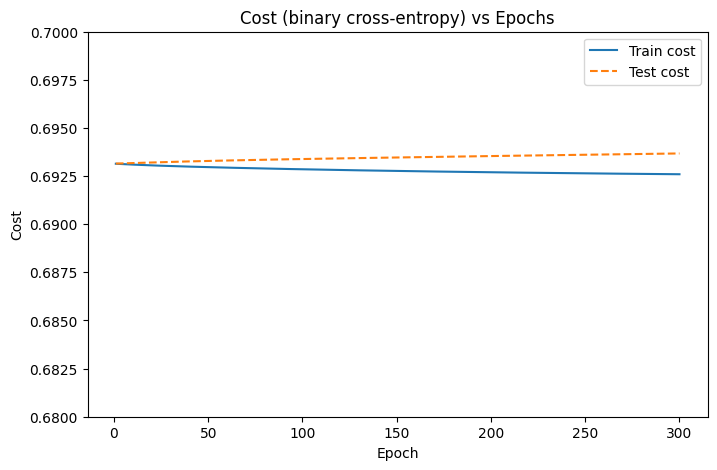

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_costs, label="Train cost")
plt.plot(range(1, epochs + 1), test_costs, label="Test cost", linestyle="--")
plt.title("Cost (binary cross-entropy) vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.ylim(0.68, 0.70)
plt.legend()
plt.show()

## Step 10: Plot the accuracy after each epoch

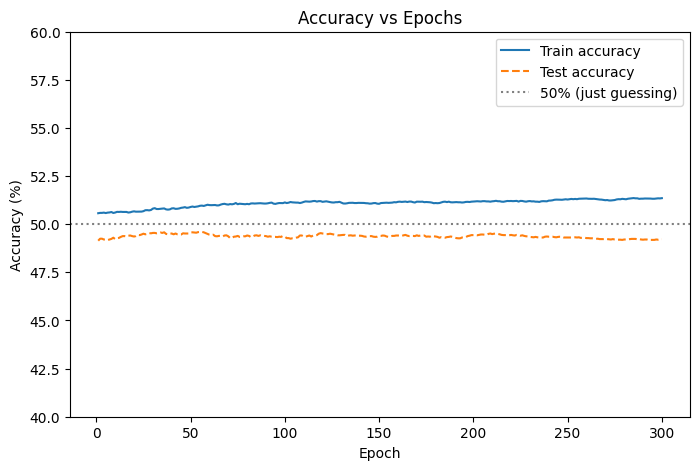

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_accs, label="Train accuracy")
plt.plot(range(1, epochs + 1), test_accs, label="Test accuracy", linestyle="--")
plt.axhline(50, color="gray", linestyle=":", label="50% (just guessing)")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim(40, 60)
plt.legend()
plt.show()

## Step 11: Final accuracy

In [11]:
print("Final train accuracy:", round(train_accs[-1], 2), "%")
print("Final test accuracy: ", round(test_accs[-1], 2), "%")

# the baseline: always predict the most common class in the train data
baseline_class = 1 if y_train.mean() >= 0.5 else 0
print("Baseline test accuracy (always guess the most common class):",
      round((y_test == baseline_class).mean() * 100, 2), "%")

Final train accuracy: 51.35 %
Final test accuracy:  49.23 %
Baseline test accuracy (always guess the most common class): 50.04 %


## Step 12: Expected vs predicted, and everything once

This prints the expected answer (the real value in the test file) next to the predicted answer, the probability the model gave, and then a summary of the cost and the accuracy.

In [12]:
test_probability = predict_proba(X_test, w)
test_prediction = predict(X_test, w)

results = pd.DataFrame({
    "Expected closed": np.where(y_test == 1, "Yes", "No"),
    "Predicted closed": np.where(test_prediction == 1, "Yes", "No"),
    "Probability of closed": test_probability,
})
results["Correct?"] = np.where(y_test == test_prediction, "yes", "no")

print("Expected vs Predicted (first 20 rows of the test file):")
print(results.head(20).round(3).to_string())

results.to_csv("test_predictions.csv", index=False)
print("All", len(results), "test predictions saved to test_predictions.csv")

# how many of each kind of right and wrong answer
true_yes = ((test_prediction == 1) & (y_test == 1)).sum()
true_no = ((test_prediction == 0) & (y_test == 0)).sum()
false_yes = ((test_prediction == 1) & (y_test == 0)).sum()
false_no = ((test_prediction == 0) & (y_test == 1)).sum()

print()
print("========== FINAL SUMMARY ==========")
print("Epochs trained:", epochs)
print("Learning rate:", learning_rate)
print("Train cost (cross-entropy):", round(cost(X_train, y_train, w), 5))
print("Test cost (cross-entropy): ", round(cost(X_test, y_test, w), 5))
print("Train accuracy:", round(accuracy(X_train, y_train, w), 2), "%")
print("Test accuracy: ", round(accuracy(X_test, y_test, w), 2), "%")
print("Test cases predicted correctly:", true_yes + true_no, "out of", len(y_test))
print("  predicted Yes and it was Yes:", true_yes)
print("  predicted No and it was No:  ", true_no)
print("  predicted Yes but it was No: ", false_yes)
print("  predicted No but it was Yes: ", false_no)

Expected vs Predicted (first 20 rows of the test file):
   Expected closed Predicted closed  Probability of closed Correct?
0              Yes               No                  0.486       no
1              Yes              Yes                  0.512      yes
2              Yes               No                  0.485       no
3              Yes              Yes                  0.527      yes
4              Yes              Yes                  0.515      yes
5               No              Yes                  0.504       no
6               No               No                  0.491      yes
7              Yes               No                  0.495       no
8               No              Yes                  0.503       no
9              Yes              Yes                  0.509      yes
10             Yes              Yes                  0.502      yes
11             Yes               No                  0.500       no
12              No               No                  0.494  

## Summary

- Cleaned the data: dropped the row-number columns, split the date into month, day, year and hour, filled the empty `weapon` cells with `None`, capped the outliers in `age` and `police_department`, and dropped `domain` (it repeats `crime_description`)
- One-hot encoded the word columns and scaled the number columns
- Built logistic regression from scratch with gradient descent (no model library)
- Recorded the cost and the train and test accuracy after every epoch
- Plotted the cost and the accuracy over the epochs
- Printed the expected and predicted answers, and one final summary

**What the results mean.** The final train accuracy is 51.35% and the final test accuracy is 49.23%. Always guessing the most common class gets 50.04%, so the model is no better than guessing. The cost barely moves (from about 0.6931 to 0.6926, where 0.693 is the cost of a model that knows nothing), and the probabilities the model gives for the test cases all stay close to 0.5 (between 0.476 and 0.527 in the first 20 rows).

This is not a bug in the code. The classes are balanced, and in Step 3 no column separates closed cases from open ones. I also tried a stronger non-linear model (outside this notebook, only to check). It reached 62% on the train file but only 49.8% on the test file, which means it memorized the train data and found no real pattern. So with the columns in this dataset, there is almost no pattern for a model to learn, and about 50% test accuracy is the honest result.